In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
# load the train and the events CSVs
events = pd.read_csv('dataset/events.csv')
outcomes = pd.read_csv('dataset/loan_outcomes_train.csv')

### Repaid Status proprtion within each Network Type

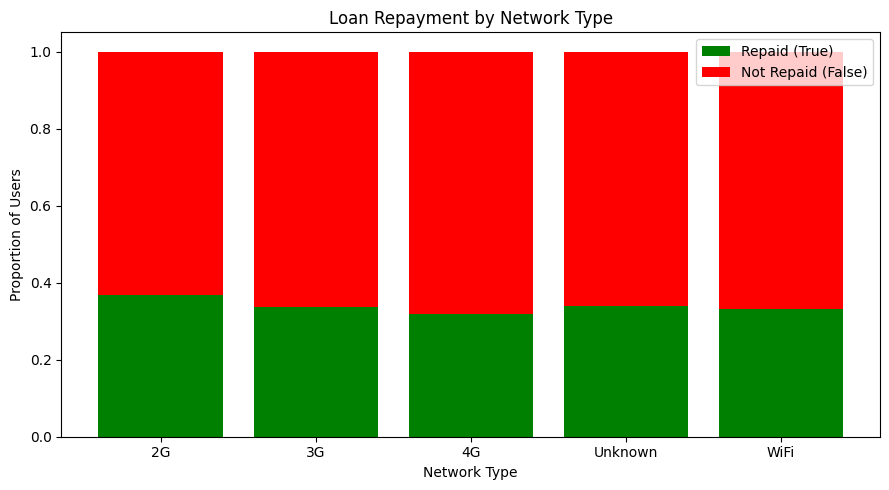

In [ ]:
# handle NaNs by creating another category called Unknown
events_viz = events.copy()
events_viz["network_type"] = events_viz["network_type"].fillna("Unknown")

df = events_viz.merge(
    outcomes[["user_id", "is_repaid"]],
    on="user_id",
    how="inner"
)

# aggregation
counts = (
    df.groupby(["network_type", "is_repaid"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.reindex(columns=[True, False], fill_value=0)

# normalisation
rates = counts.div(counts.sum(axis=1), axis=0)

# vizualisation
plt.figure(figsize=(9, 5))

plt.bar(rates.index, rates[True], label="Repaid (True)", color="green")
plt.bar(rates.index, rates[False], bottom=rates[True], label="Not Repaid (False)", color="red")

plt.xlabel("Network Type")
plt.ylabel("Proportion of Users")
plt.title("Loan Repayment by Network Type")
plt.legend()

plt.tight_layout()
plt.show()


### Proportion for each Action which led to failure/success in repayment

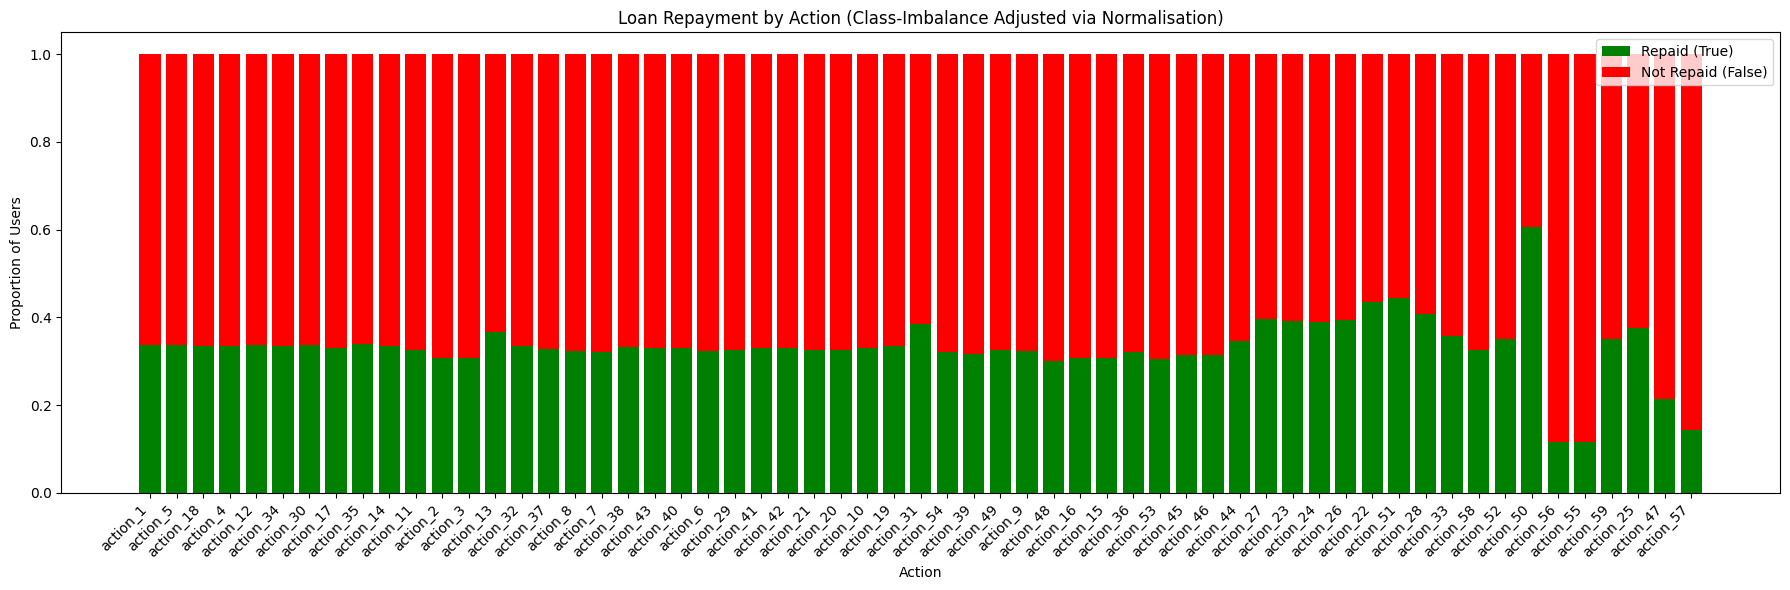

In [28]:
# inner join
df = events.merge(
    outcomes[["user_id", "is_repaid"]],
    on="user_id",
    how="inner"
)

# agg via count
counts = (
    df.groupby(["action", "is_repaid"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
)

top_actions = counts.sum(axis=1).sort_values(ascending=False).head(100).index
counts = counts.loc[top_actions]

# normalisation
rates = counts.div(counts.sum(axis=1), axis=0)

# stacked bar plot viz
plt.figure(figsize=(18, 6))

plt.bar(
    rates.index,
    rates[True],
    label="Repaid (True)",
    color="green"
)

plt.bar(
    rates.index,
    rates[False],
    bottom=rates[True],
    label="Not Repaid (False)",
    color="red"
)

plt.xlabel("Action")
plt.ylabel("Proportion of Users")
plt.title("Loan Repayment by Action (Class-Imbalance Adjusted via Normalisation)")
plt.xticks(rotation=45, ha="right")
plt.legend()

plt.tight_layout()
plt.show()


### Top 50 Screens with Highest and Lowest Success in Repayment Rates (Unigrams)

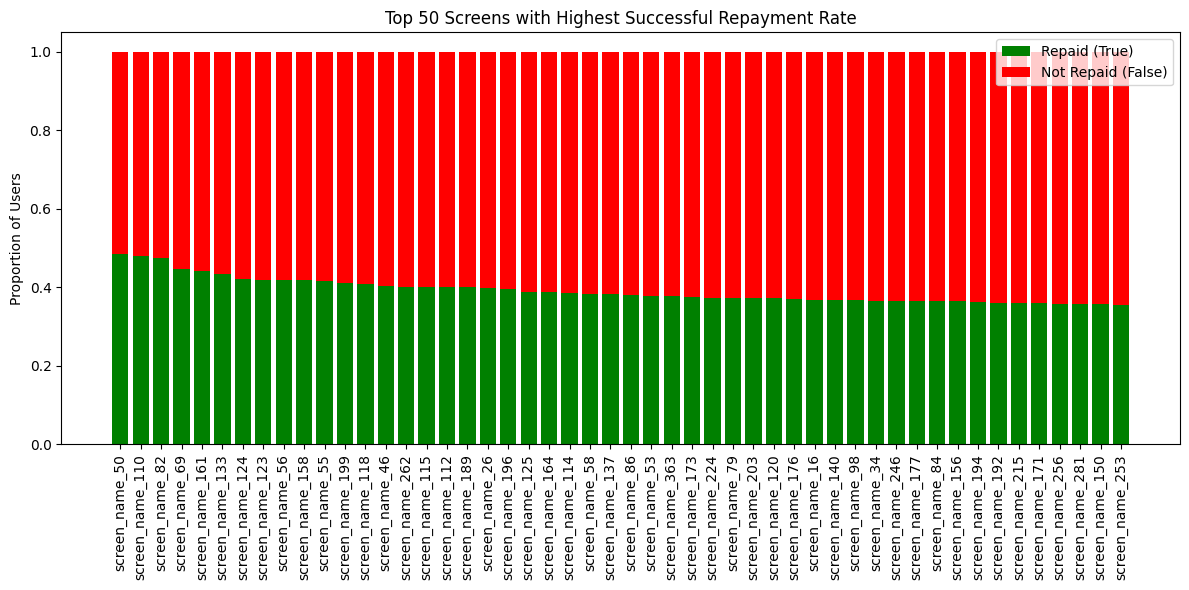

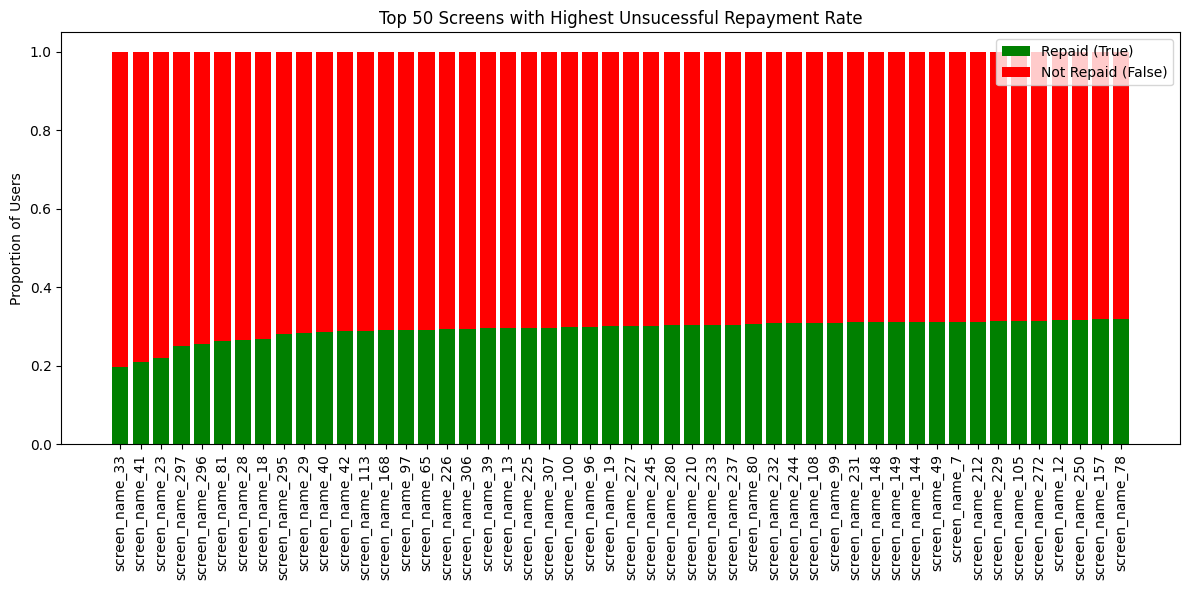

In [29]:
MIN_USERS = 80  # setting to 1% of train samples of user_ids

df = events.merge(
    outcomes[["user_id", "is_repaid"]],
    on="user_id",
    how="inner"
)

counts = (
    df.groupby(["screen_name", "is_repaid"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
)

# filtering coz i do not need extremely low accessed screens by users popping up
counts = counts[counts.sum(axis=1) >= MIN_USERS]
rates = counts.div(counts.sum(axis=1), axis=0)

# select top 50 and bottom 50 essentially screens which led to most failures to repay and most sucess to repay
top_true = rates.sort_values(True, ascending=False).head(50)
top_false = rates.sort_values(False, ascending=False).head(50)

#plot for vizualisaiton
def plot_stacked(df_rates, title):
    plt.figure(figsize=(12, 6))
    plt.bar(df_rates.index, df_rates[True], label="Repaid (True)", color="green")
    plt.bar(
        df_rates.index,
        df_rates[False],
        bottom=df_rates[True],
        label="Not Repaid (False)",
        color="red"
    )
    plt.xticks(rotation=90)
    plt.ylabel("Proportion of Users")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_stacked(top_true, "Top 50 Screens with Highest Successful Repayment Rate")
plot_stacked(top_false, "Top 50 Screens with Highest Unsucessful Repayment Rate")


### Viz of Bigrams (screen_name_x -> screen_name_y pairs)

Just to see if the transition from one particular screen to next led to failure to repay

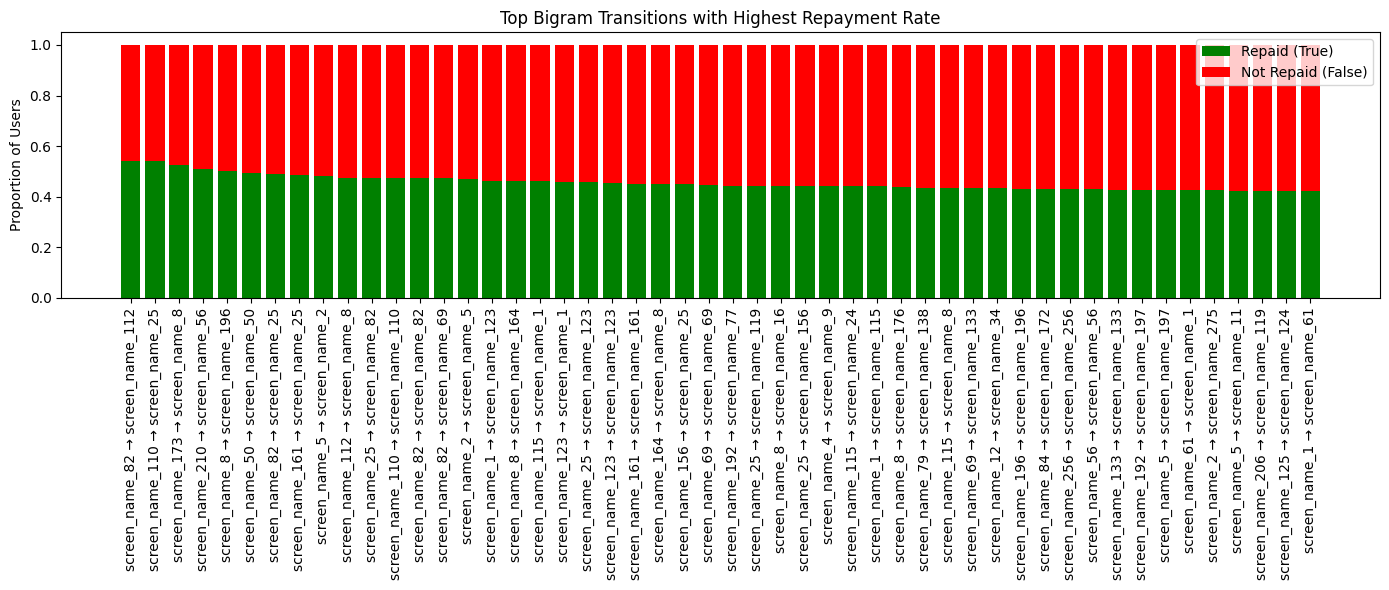

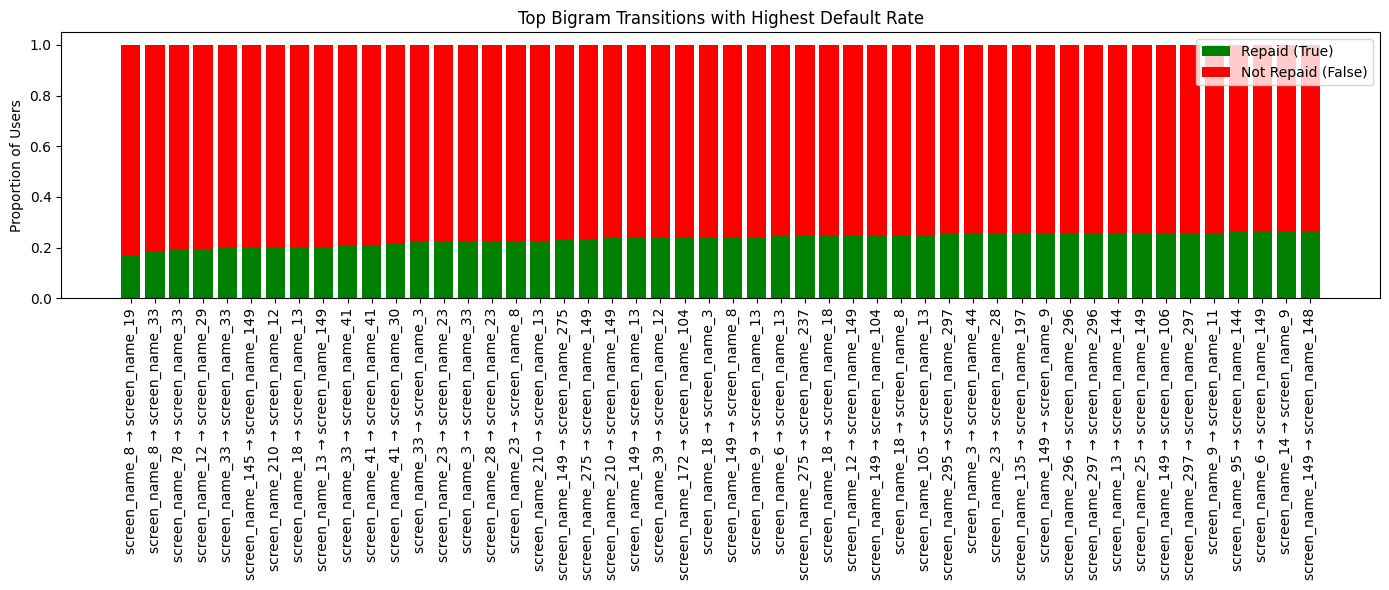

In [ ]:

TOP_K_SCREENS = 10 # reduce screens to consider (good choice to reduce sample space since there are 516 screens)
MIN_USERS_BIGRAM = 80 # 1% of 8089 users
TOP_PLOT = 50 # top 50 good / bad bigrams similar to above plots

df = (
    events
    .merge(
        outcomes[["user_id", "application_at", "is_repaid"]],
        on="user_id",
        how="inner"
    )
    .query("timestamp < application_at")
)

# currently sorting via timestamps and user_id
df = df.sort_values(["user_id", "timestamp"])

# 
df["next_screen"] = df.groupby("user_id")["screen_name"].shift(-1)

# DROP LAST EVENT PER USER (NO NEXT SCREEN)
df = df.dropna(subset=["next_screen"])

# CREATE BIGRAM
df["bigram"] = df["screen_name"] + " → " + df["next_screen"]

# counting unique bigrmas
counts = (
    df.groupby(["bigram", "is_repaid"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
)
counts = counts.reindex(columns=[True, False], fill_value=0)

# filtering out unecessary bigrmas accessed < 80
counts = counts[counts.sum(axis=1) >= MIN_USERS_BIGRAM]

#normalise
rates = counts.div(counts.sum(axis=1), axis=0)

# top k
top_good = rates.sort_values(True, ascending=False).head(TOP_PLOT)
top_bad  = rates.sort_values(False, ascending=False).head(TOP_PLOT)

# viz plot
def plot_bigram(df_rates, title):
    plt.figure(figsize=(14, 6))
    plt.bar(df_rates.index, df_rates[True], label="Repaid (True)", color="green")
    plt.bar(
        df_rates.index,
        df_rates[False],
        bottom=df_rates[True],
        label="Not Repaid (False)",
        color="red"
    )
    plt.xticks(rotation=90)
    plt.ylabel("Proportion of Users")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_bigram(top_good, "Top Bigram Transitions with Highest Repayment Rate")
plot_bigram(top_bad,  "Top Bigram Transitions with Highest Default Rate")


### Screen_Name x Action Interaction Matrix

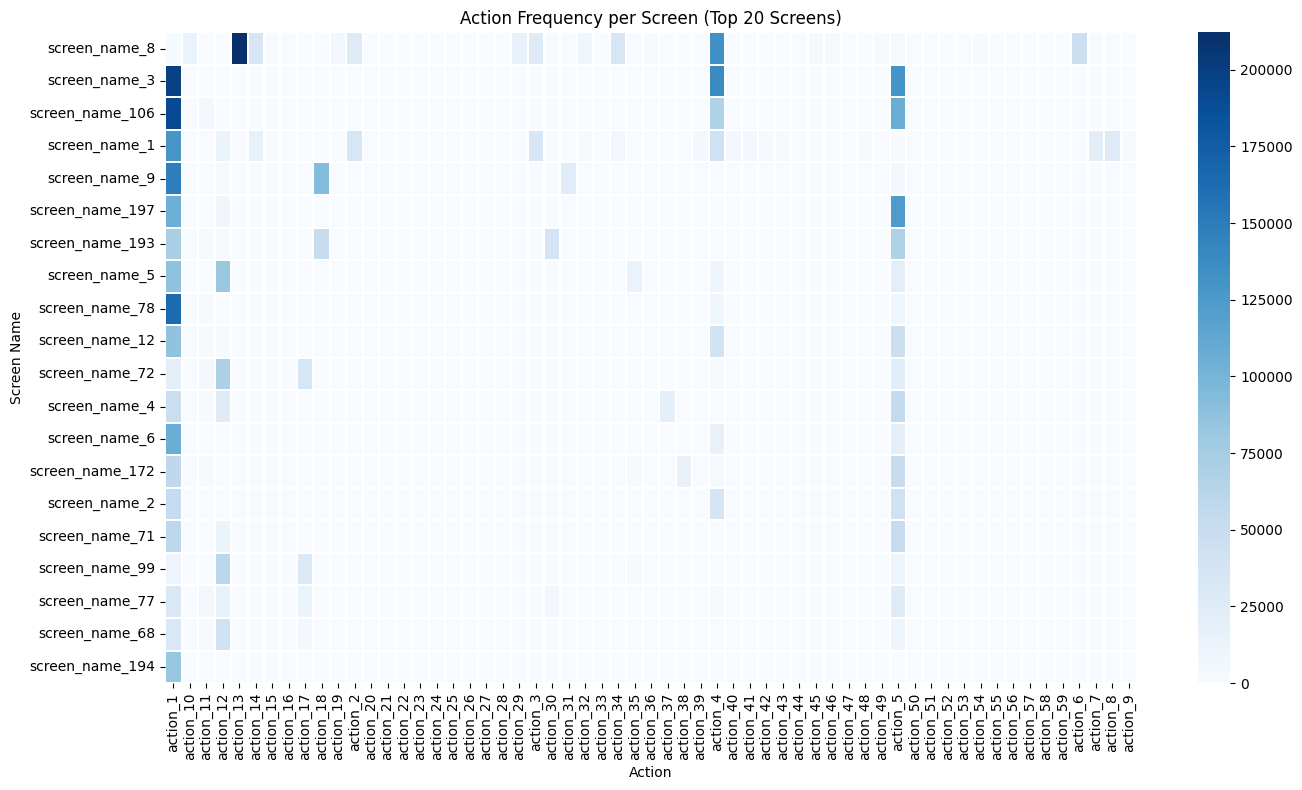

In [ ]:
# aggregation
counts = events.groupby('screen_name')['action'].value_counts()

# convert to df
df = counts.rename('count').reset_index()

# pivot for heatmap
pivot = df.pivot(
    index='screen_name',
    columns='action',
    values='count'
).fillna(0)

top_screens = (
    df.groupby('screen_name')['count']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

pivot_top = pivot.loc[top_screens]

# plot viz
plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_top,
    cmap='Blues',
    linewidths=0.3
)

plt.title('Action Frequency per Screen (Top 20 Screens)')
plt.xlabel('Action')
plt.ylabel('Screen Name')
plt.tight_layout()
plt.show()

### Same Matrix as above Log scaled and with all 526x59 screen_name-action pairs

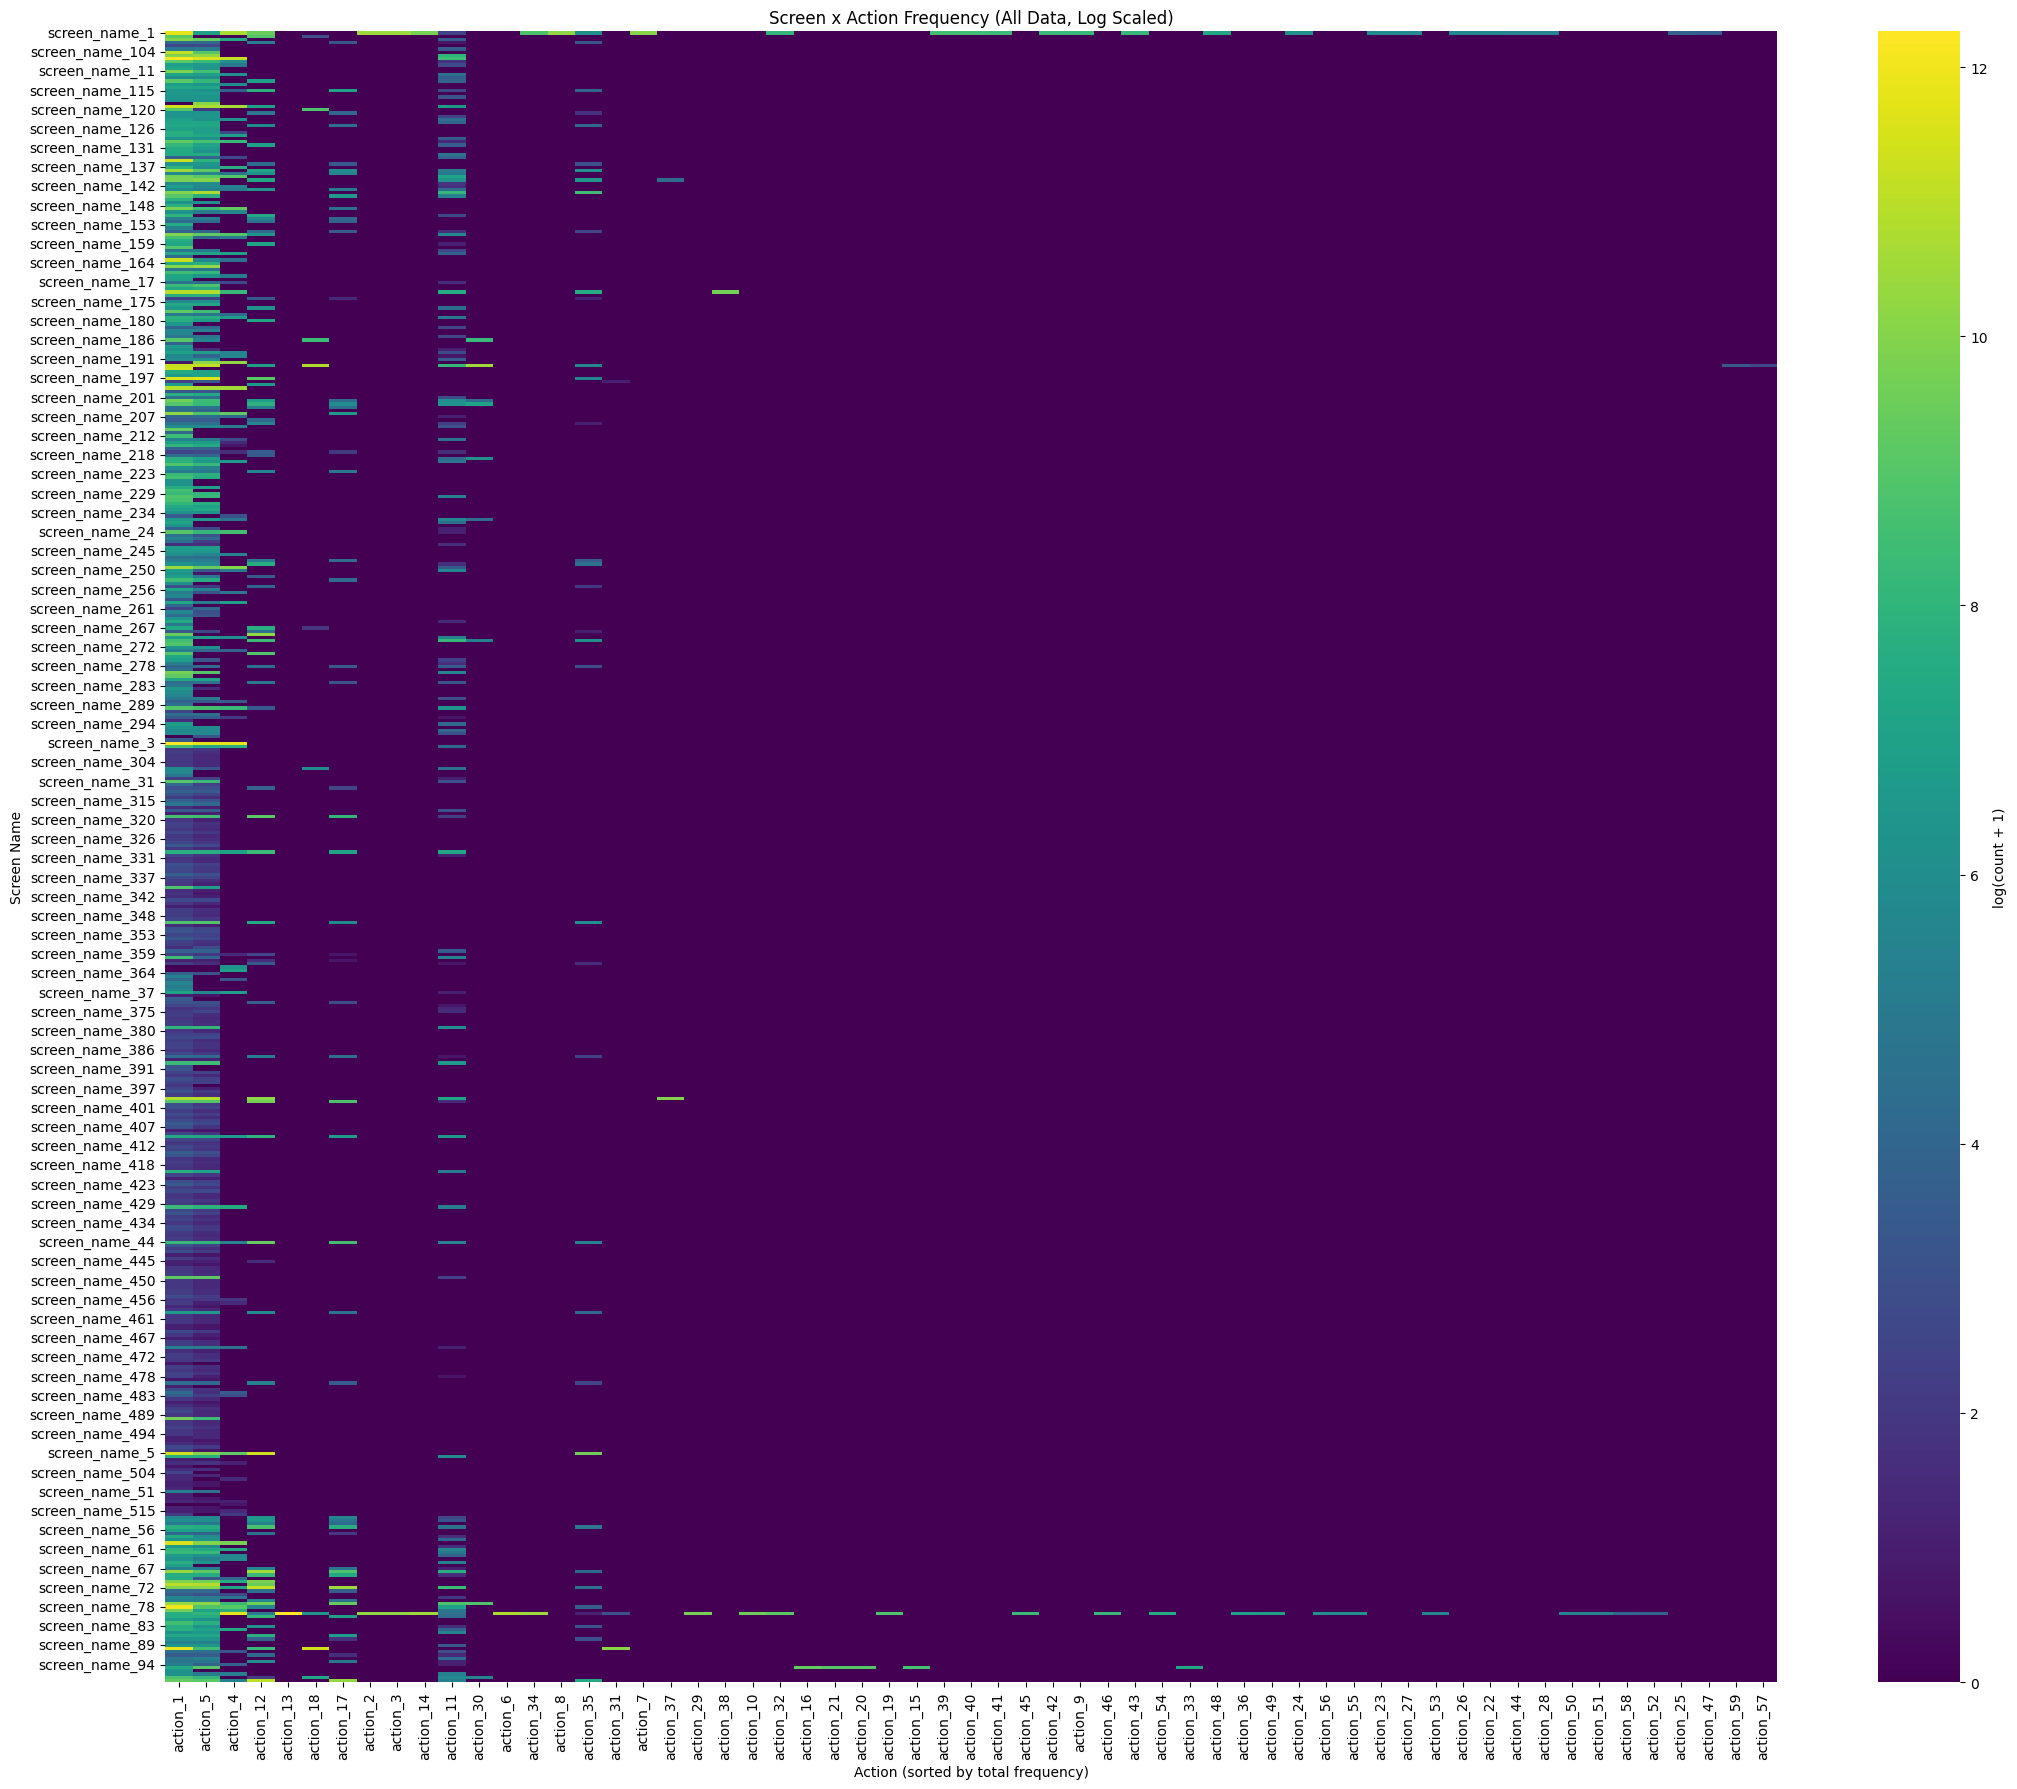

In [33]:
counts = (
    events.groupby('screen_name')['action']
    .value_counts()
    .rename('count')
    .reset_index()
)

pivot = counts.pivot(
    index='screen_name',
    columns='action',
    values='count'
).fillna(0)

# sort action in descending
action_order = pivot.sum(axis=0).sort_values(ascending=False).index
pivot = pivot[action_order]

# log transform
pivot_log = np.log1p(pivot)

# plot viz
plt.figure(figsize=(22, 18))
sns.heatmap(
    pivot_log,
    cmap='viridis',
    cbar_kws={'label': 'log(count + 1)'}
)

plt.title('Screen x Action Frequency (All Data, Log Scaled)')
plt.xlabel('Action (sorted by total frequency)')
plt.ylabel('Screen Name')
plt.tight_layout()
plt.show()


### Unique Phone Instance ID Count

In [36]:
events.groupby('user_id')['phone_instance_id'].nunique()

user_id
1        3
2        1
3        1
4        2
5        1
        ..
10107    7
10108    1
10109    7
10110    1
10111    6
Name: phone_instance_id, Length: 10111, dtype: int64